# Taller B4-T1 - Diseño de Redes Confiables

# Punto 1: arquitectura customizada con ratio de endeudamiento

Este notebook implementa **solo el primer punto de la práctica**: una arquitectura de red neuronal que incorpora una capa customizada para calcular ratios financieros internos antes de alimentar las capas densas.

El objetivo no es todavía resolver la parte completa de justicia, incertidumbre o comparación entre modelos, sino construir una base fiable y trazable sobre la que después se podrán añadir FAIR loss, AutoML, estimación de incertidumbre y análisis de Pareto.


Vamos a trabajar con el dataset `application_train.csv` de Home Credit Default Risk y construiremos un modelo binario para predecir `TARGET`:

- `TARGET = 1`: cliente con dificultades de pago.
- `TARGET = 0`: cliente sin dificultades de pago.

La aportación principal de esta primera versión es la capa `DebtBurdenLayer`, que calcula dentro del modelo dos indicadores financieros interpretables:

- cuota anual sobre ingresos: `AMT_ANNUITY / AMT_INCOME_TOTAL`;
- crédito total sobre ingresos: `AMT_CREDIT / AMT_INCOME_TOTAL`.

Estos ratios se calculan con variables monetarias en bruto, no con variables escaladas, para conservar su significado económico.

In [24]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight

RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

DATA_PATH = Path("data") / "application_train.csv"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

## Por qué no usamos `CODE_GENDER` como entrada

`CODE_GENDER` se trata como **variable sensible**. La guardamos aparte porque será necesaria para auditar diferencias entre grupos y, más adelante, para diseñar o evaluar restricciones de justicia.

En esta primera arquitectura no se incluye como entrada directa del modelo. De este modo evitamos que la red utilice explícitamente el género para optimizar la predicción. Esto no garantiza justicia por sí solo, porque otras variables pueden contener información correlacionada con el género, pero deja preparada una separación clara entre:

- variables predictoras usadas por la red;
- variable sensible usada para auditoría y futuras pérdidas FAIR.

## Carga y preprocesado de datos

La función `load_home_credit_data` realiza un preprocesado cuidadoso y evita fugas de información entre entrenamiento, validación y test:

- lee únicamente las columnas necesarias para este punto;
- elimina los casos `CODE_GENDER == "XNA"`;
- convierte `CODE_GENDER` a una variable binaria sensible (`M -> 0`, `F -> 1`);
- transforma `DAYS_BIRTH` en edad positiva en años;
- separa `y`, `s` y las variables de entrada del modelo;
- crea dos ramas de entrada: una escalada y otra financiera en bruto;
- separa explícitamente `train`, `validation` y `test`;
- ajusta imputador y escalador solo con `train`;
- aplica esas transformaciones a `validation` y `test` sin recalcular parámetros.

In [25]:
def load_home_credit_data(file_path):
    """Carga y prepara los datos de Home Credit para la arquitectura customizada.

    La función devuelve tres subconjuntos separados: train, validation y test.
    Cada subconjunto contiene:
    1. variables predictoras imputadas y escaladas;
    2. variables financieras imputadas en bruto, sin escalar;
    3. etiqueta binaria `TARGET` en formato float32 para Keras;
    4. variable sensible `CODE_GENDER` conservada aparte para auditoría.

    La rama financiera se mantiene en escala monetaria real porque los ratios de
    `DebtBurdenLayer` deben calcularse sobre importes originales o imputados, no
    sobre z-scores.
    """

    selected_cols = [
        "TARGET",
        "CODE_GENDER",
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "DAYS_BIRTH",
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3",
    ]

    df = pd.read_csv(file_path, usecols=selected_cols)
    df = df.loc[df["CODE_GENDER"] != "XNA"].copy()

    # Flags de missingness calculados antes de imputar. No entran todavía como
    # inputs del modelo, pero quedan disponibles para incertidumbre y auditoría.
    ext_source_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
    missing_flag_cols = [f"{col}_missing" for col in ext_source_cols]
    ext_source_missing_flags = df[ext_source_cols].isna().astype("int32")
    ext_source_missing_flags.columns = missing_flag_cols

    ext_source_missingness_summary = pd.DataFrame(
        {
            "variable": ext_source_cols,
            "missing_count": df[ext_source_cols].isna().sum().to_numpy(),
            "missing_rate": df[ext_source_cols].isna().mean().to_numpy(),
        }
    )

    # Variable sensible codificada y conservada fuera del input del modelo.
    df["CODE_GENDER"] = df["CODE_GENDER"].map({"M": 0, "F": 1}).astype(int)

    # Edad positiva en años. La columna original se elimina para evitar duplicar
    # la misma información con dos escalas distintas.
    df["AGE_YEARS"] = np.abs(df["DAYS_BIRTH"]) / 365.25
    df = df.drop(columns=["DAYS_BIRTH"])

    scaled_features = [
        "AMT_INCOME_TOTAL",
        "AMT_CREDIT",
        "AMT_ANNUITY",
        "AGE_YEARS",
        "EXT_SOURCE_1",
        "EXT_SOURCE_2",
        "EXT_SOURCE_3",
    ]
    financial_features = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY"]

    X = df[scaled_features].copy()
    y = df["TARGET"].astype(int)
    s = df["CODE_GENDER"].astype(int)

    # Primer split: separamos test y no lo tocamos durante entrenamiento ni
    # selección de hiperparámetros.
    (
        X_trainval,
        X_test,
        missing_trainval,
        missing_test,
        y_trainval,
        y_test,
        s_trainval,
        s_test,
    ) = train_test_split(
        X,
        ext_source_missing_flags,
        y,
        s,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    # Segundo split: separamos validation desde trainval. El reparto final queda
    # aproximadamente en 64 % train, 16 % validation y 20 % test.
    (
        X_train,
        X_val,
        missing_train,
        missing_val,
        y_train,
        y_val,
        s_train,
        s_val,
    ) = train_test_split(
        X_trainval,
        missing_trainval,
        y_trainval,
        s_trainval,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_trainval,
    )

    # Imputación ajustada solo con train. Validation y test se transforman con el
    # mismo imputador para evitar data leakage.
    imputer = SimpleImputer(strategy="median")
    X_train_imputed = pd.DataFrame(
        imputer.fit_transform(X_train),
        columns=X_train.columns,
        index=X_train.index,
    )
    X_val_imputed = pd.DataFrame(
        imputer.transform(X_val),
        columns=X_val.columns,
        index=X_val.index,
    )
    X_test_imputed = pd.DataFrame(
        imputer.transform(X_test),
        columns=X_test.columns,
        index=X_test.index,
    )

    # Rama financiera: datos imputados, pero no escalados. Así los ratios internos
    # siguen teniendo interpretación económica.
    X_train_financial_raw = X_train_imputed[financial_features].astype("float32")
    X_val_financial_raw = X_val_imputed[financial_features].astype("float32")
    X_test_financial_raw = X_test_imputed[financial_features].astype("float32")

    # Rama principal: escalado ajustado solo con train.
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train_imputed[scaled_features]),
        columns=scaled_features,
        index=X_train_imputed.index,
    )
    X_val_scaled = pd.DataFrame(
        scaler.transform(X_val_imputed[scaled_features]),
        columns=scaled_features,
        index=X_val_imputed.index,
    )
    X_test_scaled = pd.DataFrame(
        scaler.transform(X_test_imputed[scaled_features]),
        columns=scaled_features,
        index=X_test_imputed.index,
    )

    X_train_scaled_np = X_train_scaled.astype("float32")
    X_val_scaled_np = X_val_scaled.astype("float32")
    X_test_scaled_np = X_test_scaled.astype("float32")

    y_train_np = y_train.astype("float32").values
    y_val_np = y_val.astype("float32").values
    y_test_np = y_test.astype("float32").values

    preprocessor = {
        "feature_cols": scaled_features,
        "financial_cols": financial_features,
        "imputer": imputer,
        "medians": pd.Series(imputer.statistics_, index=scaled_features),
        "scaler": scaler,
        "missing_flag_cols": missing_flag_cols,
        "ext_source_missing_train": missing_train.reset_index(drop=True),
        "ext_source_missing_val": missing_val.reset_index(drop=True),
        "ext_source_missing_test": missing_test.reset_index(drop=True),
        "ext_source_missingness_summary": ext_source_missingness_summary,
    }

    return (
        X_train_scaled_np,
        X_train_financial_raw,
        y_train_np,
        s_train,
    ), (
        X_val_scaled_np,
        X_val_financial_raw,
        y_val_np,
        s_val,
    ), (
        X_test_scaled_np,
        X_test_financial_raw,
        y_test_np,
        s_test,
    ), preprocessor

## Split explícito train / validation / test

En esta versión sustituimos la partición automática de validación por un conjunto de validación explícito. Esto permite conservar también la variable sensible `CODE_GENDER` en validación (`s_val`), lo cual será necesario para la siguiente fase de la práctica: medir y penalizar la dependencia entre las predicciones del modelo y la variable sensible.

El conjunto de test se mantiene separado y no se usa durante el entrenamiento ni durante la selección de hiperparámetros.

Antes de entrenar el modelo conviene comprobar que las ramas tienen las formas esperadas y que las distribuciones principales se conservan tras el split.

In [26]:
(
    X_train_scaled_np,
    X_train_financial_raw,
    y_train_np,
    s_train,
), (
    X_val_scaled_np,
    X_val_financial_raw,
    y_val_np,
    s_val,
), (
    X_test_scaled_np,
    X_test_financial_raw,
    y_test_np,
    s_test,
), preprocessor = load_home_credit_data(DATA_PATH)

print("Shape de X_train_scaled_np:", X_train_scaled_np.shape)
print("Shape de X_val_scaled_np:", X_val_scaled_np.shape)
print("Shape de X_test_scaled_np:", X_test_scaled_np.shape)
print("Shape de X_train_financial_raw:", X_train_financial_raw.shape)
print("Shape de X_val_financial_raw:", X_val_financial_raw.shape)
print("Shape de X_test_financial_raw:", X_test_financial_raw.shape)
print("Shape de y_train_np:", y_train_np.shape)
print("Shape de y_val_np:", y_val_np.shape)
print("Shape de y_test_np:", y_test_np.shape)

print("\ns_train shape:", s_train.shape)
print("s_val shape:", s_val.shape)
print("s_test shape:", s_test.shape)

print("\nColumnas de la rama escalada:")
print(preprocessor["feature_cols"])

print("\nColumnas de la rama financiera en bruto:")
print(preprocessor["financial_cols"])

print("\nFlags de missingness preparados para análisis posterior:")
print(preprocessor["missing_flag_cols"])

missingness_path = OUTPUT_DIR / "ext_source_missingness_summary.csv"
preprocessor["ext_source_missingness_summary"].to_csv(missingness_path, index=False)
print(f"\nResumen de missingness guardado en: {missingness_path}")
display(preprocessor["ext_source_missingness_summary"])

Shape de X_train_scaled_np: (196804, 7)
Shape de X_val_scaled_np: (49201, 7)
Shape de X_test_scaled_np: (61502, 7)
Shape de X_train_financial_raw: (196804, 3)
Shape de X_val_financial_raw: (49201, 3)
Shape de X_test_financial_raw: (61502, 3)
Shape de y_train_np: (196804,)
Shape de y_val_np: (49201,)
Shape de y_test_np: (61502,)

s_train shape: (196804,)
s_val shape: (49201,)
s_test shape: (61502,)

Columnas de la rama escalada:
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AGE_YEARS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

Columnas de la rama financiera en bruto:
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']

Flags de missingness preparados para análisis posterior:
['EXT_SOURCE_1_missing', 'EXT_SOURCE_2_missing', 'EXT_SOURCE_3_missing']

Resumen de missingness guardado en: outputs\ext_source_missingness_summary.csv


,variable,missing_count,missing_rate
0,EXT_SOURCE_1,173376,0.563812
1,EXT_SOURCE_2,660,0.002146
2,EXT_SOURCE_3,60965,0.198256


In [27]:
# Distribución de TARGET en train, validation y test. normalize=True muestra
# proporciones, útil porque el problema está desbalanceado hacia la clase 0.
print("Distribución de TARGET en train:")
print(pd.Series(y_train_np, name="TARGET").value_counts(normalize=True).sort_index())

print("\nDistribución de TARGET en validation:")
print(pd.Series(y_val_np, name="TARGET").value_counts(normalize=True).sort_index())

print("\nDistribución de TARGET en test:")
print(pd.Series(y_test_np, name="TARGET").value_counts(normalize=True).sort_index())

# Distribución de la variable sensible. Esta información no se usa como input
# del modelo, pero se conserva para los siguientes puntos de justicia.
print("\nDistribución de CODE_GENDER en train (0=M, 1=F):")
print(s_train.value_counts(normalize=True).sort_index())

print("\nDistribución de CODE_GENDER en validation (0=M, 1=F):")
print(s_val.value_counts(normalize=True).sort_index())

print("\nDistribución de CODE_GENDER en test (0=M, 1=F):")
print(s_test.value_counts(normalize=True).sort_index())

Distribución de TARGET en train:
TARGET
0.0    0.91927
1.0    0.08073
Name: proportion, dtype: float64

Distribución de TARGET en validation:
TARGET
0.0    0.91927
1.0    0.08073
Name: proportion, dtype: float64

Distribución de TARGET en test:
TARGET
0.0    0.919271
1.0    0.080729
Name: proportion, dtype: float64

Distribución de CODE_GENDER en train (0=M, 1=F):
CODE_GENDER
0    0.341939
1    0.658061
Name: proportion, dtype: float64

Distribución de CODE_GENDER en validation (0=M, 1=F):
CODE_GENDER
0    0.341578
1    0.658422
Name: proportion, dtype: float64

Distribución de CODE_GENDER en test (0=M, 1=F):
CODE_GENDER
0    0.340769
1    0.659231
Name: proportion, dtype: float64


### Interpretación del desbalance de clases

La variable objetivo está fuertemente desbalanceada. Aproximadamente el 92 % de los clientes pertenecen a la clase `TARGET = 0` y solo alrededor del 8 % pertenecen a la clase `TARGET = 1`.

Esto implica que la métrica `accuracy` debe interpretarse con cautela. Un modelo trivial que predijera siempre “buen pagador” obtendría una accuracy muy alta, pero no detectaría ningún cliente con dificultades de pago.

Por este motivo, en este problema son especialmente relevantes métricas como AUC, recall de la clase minoritaria, precision de la clase minoritaria y balanced accuracy.

In [28]:
# Primeras filas de la rama financiera en bruto. Deben verse como importes
# monetarios originales, no como variables centradas alrededor de cero.
X_train_financial_raw.head(10)

,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY
1228,90000.0,203760.0,11826.0
162360,67500.0,180000.0,9000.0
68610,315000.0,1125000.0,44019.0
122818,225000.0,156384.0,16155.0
274639,135000.0,573628.5,24435.0
154292,211500.0,729567.0,27166.5
290325,180000.0,113076.0,5773.5
176690,112500.0,381528.0,22032.0
156479,67500.0,343800.0,16155.0
212749,121500.0,942300.0,30528.0


## Por qué calculamos ratios financieros en una capa customizada

Una red densa estándar puede aprender interacciones entre variables, pero no sabe de partida que ciertos cocientes financieros son especialmente relevantes.

La capa customizada introduce conocimiento previo del dominio:

- una cuota anual alta respecto a ingresos puede indicar mayor presión financiera;
- un crédito alto respecto a ingresos puede indicar mayor exposición al endeudamiento.

Al calcular estos ratios dentro del grafo de TensorFlow, la transformación queda integrada en el modelo, aparece en `model.summary()` y puede serializarse junto con la arquitectura.

## Flags de missingness para `EXT_SOURCE`

Las variables `EXT_SOURCE_1`, `EXT_SOURCE_2` y `EXT_SOURCE_3` tienen valores ausentes. En este punto los valores se imputan con medianas calculadas solo en train, pero además conservamos tres indicadores auxiliares:

- `EXT_SOURCE_1_missing`;
- `EXT_SOURCE_2_missing`;
- `EXT_SOURCE_3_missing`.

Estos flags valen 1 si el dato original estaba ausente y 0 si estaba informado. No se usan todavía como entrada de la arquitectura principal, pero quedan preparados para el análisis posterior de incertidumbre. El resumen de missingness se guarda en `outputs/ext_source_missingness_summary.csv`.

## Por qué se usa `tanh` como saturación

Los ratios financieros pueden tomar valores extremos cuando los ingresos son bajos o cuando el crédito es muy alto. Si se pasan directamente a la red, esos valores pueden dominar el entrenamiento.

Usamos `tanh` porque es una saturación suave y diferenciable:

- mantiene el entrenamiento compatible con backpropagation;
- comprime valores extremos;
- conserva una señal ordenada: ratios más altos producen salidas saturadas más altas;
- reduce el impacto de outliers sin aplicar cortes bruscos.

### Interpretación de la capa `DebtBurdenLayer`

La capa customizada introduce conocimiento financiero dentro de la arquitectura neuronal.

En lugar de dejar que la red aprenda desde cero todas las relaciones entre ingresos, crédito y anualidad, calculamos explícitamente dos ratios interpretables:

- cuota anual sobre ingresos;
- crédito total sobre ingresos.

Después aplicamos una saturación suave mediante `tanh`. Esta saturación evita que ratios extremos dominen el entrenamiento, pero conserva el orden económico de la señal: ratios más altos siguen generando valores más altos.

La capa no tiene parámetros entrenables. Su función es imponer una transformación financiera razonable antes de pasar la información a las capas densas.

In [29]:
class DebtBurdenLayer(tf.keras.layers.Layer):
    """Capa customizada para calcular ratios de endeudamiento saturados.

    La capa recibe tres columnas en este orden:
    [AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY]

    Devuelve dos columnas:
    1. `annuity_ratio_sat`: cuota anual sobre ingresos, saturada con tanh.
    2. `credit_ratio_sat`: crédito total sobre ingresos, saturado con tanh.
    """

    def __init__(self, annuity_tau=0.5, credit_tau=5.0, epsilon=1e-6, **kwargs):
        super().__init__(**kwargs)
        self.annuity_tau = annuity_tau
        self.credit_tau = credit_tau
        self.epsilon = epsilon

    def call(self, inputs):
        # Separación explícita de columnas. Usamos rangos como 0:1 para mantener
        # tensores bidimensionales de shape (batch_size, 1), lo que facilita la
        # concatenación posterior.
        income = inputs[:, 0:1]
        credit = inputs[:, 1:2]
        annuity = inputs[:, 2:3]

        # Ratios financieros sobre variables monetarias originales. epsilon evita
        # divisiones por cero si apareciera algún ingreso nulo.
        annuity_income_ratio = annuity / (income + self.epsilon)
        credit_income_ratio = credit / (income + self.epsilon)

        # Saturación suave. Los parámetros tau controlan la escala a partir de la
        # cual cada ratio empieza a acercarse a 1.
        annuity_ratio_sat = tf.math.tanh(annuity_income_ratio / self.annuity_tau)
        credit_ratio_sat = tf.math.tanh(credit_income_ratio / self.credit_tau)

        # El resultado final tiene dos columnas y puede concatenarse con la rama
        # principal de variables escaladas.
        return tf.concat([annuity_ratio_sat, credit_ratio_sat], axis=1)

    def get_config(self):
        # Permite guardar y recargar modelos que incluyan esta capa customizada.
        config = super().get_config()
        config.update(
            {
                "annuity_tau": self.annuity_tau,
                "credit_tau": self.credit_tau,
                "epsilon": self.epsilon,
            }
        )
        return config

## Comprobación de la capa customizada

Probamos `DebtBurdenLayer` sobre cinco ejemplos reales de la rama financiera. La salida debe tener dos columnas y valores aproximadamente entre 0 y 1, porque los importes son positivos y `tanh` satura por arriba.

In [30]:
# Instanciamos la capa de forma aislada para verificar su comportamiento antes
# de integrarla en el modelo funcional.
debt_layer_check = DebtBurdenLayer(name="debt_burden_layer_check")
ratio_examples = debt_layer_check(X_train_financial_raw.iloc[:5].to_numpy()).numpy()

ratio_check_df = pd.DataFrame(
    ratio_examples,
    columns=["annuity_ratio_sat", "credit_ratio_sat"],
)

print("Shape de la salida de DebtBurdenLayer:", ratio_examples.shape)
print("\nPrimeros ratios saturados:")
display(ratio_check_df)

print("\nMínimos por columna:")
print(ratio_check_df.min())

print("\nMáximos por columna:")
print(ratio_check_df.max())

Shape de la salida de DebtBurdenLayer: (5, 2)

Primeros ratios saturados:


,annuity_ratio_sat,credit_ratio_sat
0,0.256913,0.424198
1,0.260520,0.487925
2,0.272429,0.613357
3,0.142621,0.138120
4,0.346974,0.690975



Mínimos por columna:
annuity_ratio_sat    0.142621
credit_ratio_sat     0.138120
dtype: float32

Máximos por columna:
annuity_ratio_sat    0.346974
credit_ratio_sat     0.690975
dtype: float32


## Modelo funcional con dos entradas

La red tiene dos ramas de entrada:

- `scaled_features`: siete variables imputadas y escaladas;
- `financial_raw`: tres variables monetarias imputadas sin escalar.

La capa `DebtBurdenLayer` transforma la rama financiera en dos ratios saturados. Después concatenamos esos dos ratios con las siete variables escaladas y entrenamos capas densas para la clasificación binaria.

In [31]:
def build_custom_debt_model(n_scaled_features):
    """Construye el modelo Keras funcional con la capa DebtBurdenLayer."""

    # Entrada principal: variables numéricas ya imputadas y estandarizadas.
    scaled_input = keras.Input(
        shape=(n_scaled_features,),
        name="scaled_features",
    )

    # Entrada financiera: importes originales imputados, sin escalar. Esta rama
    # existe exclusivamente para calcular ratios interpretables dentro del modelo.
    financial_raw_input = keras.Input(
        shape=(3,),
        name="financial_raw",
    )

    # Capa customizada solicitada en la práctica. Debe aparecer en model.summary().
    ratios = DebtBurdenLayer(name="debt_burden_layer")(financial_raw_input)

    # Unimos las variables escaladas con los ratios financieros calculados por
    # la red. El tensor resultante tiene 7 + 2 = 9 variables.
    x = layers.Concatenate(name="concat_scaled_and_custom_ratios")(
        [scaled_input, ratios]
    )

    # Bloque denso sencillo. BatchNormalization ayuda a estabilizar activaciones
    # intermedias; Dropout reduce sobreajuste en una tabla con muchas filas.
    x = layers.Dense(64, activation="relu", name="dense_64")(x)
    x = layers.BatchNormalization(name="batch_norm_64")(x)
    x = layers.Dropout(0.25, name="dropout_025")(x)

    x = layers.Dense(32, activation="relu", name="dense_32")(x)
    x = layers.Dropout(0.15, name="dropout_015")(x)

    # Salida binaria: probabilidad estimada de TARGET = 1.
    output = layers.Dense(1, activation="sigmoid", name="default_probability")(x)

    model = keras.Model(
        inputs=[scaled_input, financial_raw_input],
        outputs=output,
        name="home_credit_custom_debt_model",
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc"),
        ],
    )

    return model


model = build_custom_debt_model(n_scaled_features=X_train_scaled_np.shape[1])
model.summary()

Model: "home_credit_custom_debt_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ financial_raw       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scaled_features     │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ debt_burden_layer   │ (None, 2)         │          0 │ financial_raw[0]… │
│ (DebtBurdenLayer)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_scaled_and_… │ (None, 9)         │          0 │ scaled_features[… │
│ (Concatenate)       │                   │            │ debt_burden_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_64 (Dense)    │ (None, 64)        │        640 │ concat_scaled_an… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_norm_64       │ (None, 64)        │        256 │ dense_64[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_025         │ (None, 64)        │          0 │ batch_norm_64[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 32)        │      2,080 │ dropout_025[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_015         │ (None, 32)        │          0 │ dense_32[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ default_probability │ (None, 1)         │         33 │ dropout_015[0][0] │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 128 (512.00 B)

## Entrenamiento

`TARGET` está desbalanceada: hay muchos más buenos pagadores que clientes con dificultades. Para compensarlo, calculamos `class_weight` con sklearn y lo pasamos a `model.fit`.

También usamos dos callbacks:

- `EarlyStopping`, para recuperar los mejores pesos según `val_auc`;
- `ReduceLROnPlateau`, para reducir la tasa de aprendizaje si `val_auc` deja de mejorar.

In [32]:
# Pesos de clase calculados solo con y_train. El objetivo es que la clase
# minoritaria tenga más peso durante la optimización.
classes = np.unique(y_train_np.astype(int))
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_np.astype(int),
)

# Conversión explícita a tipos nativos de Python para evitar impresiones como
# np.int64(0) o np.float64(...), y para mantener compatibilidad clara con Keras.
class_weight = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_values)
}

print("Class weights:", class_weight)

EPOCHS = 100
BATCH_SIZE = 1024

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1,
    ),
]

history = model.fit(
    x={
        "scaled_features": X_train_scaled_np,
        "financial_raw": X_train_financial_raw,
    },
    y=y_train_np,
    validation_data=(
        {
            "scaled_features": X_val_scaled_np,
            "financial_raw": X_val_financial_raw,
        },
        y_val_np,
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1,
)

Class weights: {0: 0.5439098808286719, 1: 6.193479355488419}
Epoch 1/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6427 - auc: 0.6856 - loss: 0.6519 - val_accuracy: 0.6423 - val_auc: 0.7233 - val_loss: 0.6503 - learning_rate: 0.0010
Epoch 2/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6524 - auc: 0.7112 - loss: 0.6242 - val_accuracy: 0.6617 - val_auc: 0.7260 - val_loss: 0.6193 - learning_rate: 0.0010
Epoch 3/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6604 - auc: 0.7192 - loss: 0.6179 - val_accuracy: 0.6571 - val_auc: 0.7264 - val_loss: 0.6168 - learning_rate: 0.0010
Epoch 4/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6584 - auc: 0.7209 - loss: 0.6160 - val_accuracy: 0.6554 - val_auc: 0.7273 - val_loss: 0.6144 - learning_rate: 0.0010
Epoch 5/100
193/193 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6611 - auc: 0.7225 - loss: 0.6148 - val_accuracy: 0.6579 - val_auc: 0.7268 - val_loss: 0.6094 - learning_rate: 0.0010
Epoch 6/100
19

## Curvas de entrenamiento

Las curvas permiten comprobar visualmente si el modelo aprende y si aparece sobreajuste. En esta práctica nos interesan especialmente:

- `loss` y `val_loss`, para ver la evolución de la función de coste;
- `auc` y `val_auc`, porque AUC es más informativa que accuracy cuando la clase positiva es minoritaria.

Histórico de entrenamiento guardado en: outputs\training_history_punto1_custom_layer.csv


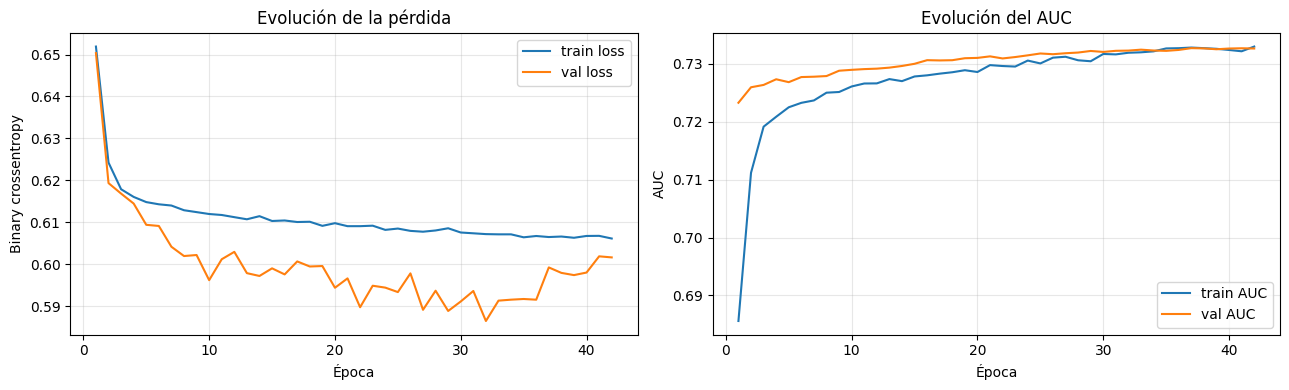

In [33]:
def plot_training_curves(history):
    """Dibuja curvas de loss y AUC para entrenamiento y validación."""

    history_df = pd.DataFrame(history.history)
    history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))

    history_path = OUTPUT_DIR / "training_history_punto1_custom_layer.csv"
    history_df.to_csv(history_path, index=False)
    print(f"Histórico de entrenamiento guardado en: {history_path}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(history_df["epoch"], history_df["loss"], label="train loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val loss")
    axes[0].set_title("Evolución de la pérdida")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel("Binary crossentropy")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history_df["epoch"], history_df["auc"], label="train AUC")
    axes[1].plot(history_df["epoch"], history_df["val_auc"], label="val AUC")
    axes[1].set_title("Evolución del AUC")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel("AUC")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_training_curves(history)

## Evaluación en test

Evaluamos sobre el subconjunto de test que no se ha usado para ajustar medianas, escalador ni pesos del modelo. Calculamos métricas básicas de clasificación y guardamos probabilidades para análisis posteriores.

In [34]:
# Evaluación nativa de Keras con las métricas definidas en compile. Se evalúa
# exclusivamente sobre test, que no se ha usado ni para entrenar ni para validar.
test_metrics = model.evaluate(
    x={
        "scaled_features": X_test_scaled_np,
        "financial_raw": X_test_financial_raw,
    },
    y=y_test_np,
    batch_size=1024,
    verbose=0,
    return_dict=True,
)

print("Métricas de test devueltas por Keras:")
print(test_metrics)

# Probabilidades de clase positiva sobre test. El umbral 0.5 se usa solo para
# obtener una predicción binaria sencilla; más adelante podría calibrarse o
# ajustarse por objetivos de justicia/riesgo.
y_test_proba = model.predict(
    {
        "scaled_features": X_test_scaled_np,
        "financial_raw": X_test_financial_raw,
    },
    batch_size=1024,
    verbose=0,
).ravel()

y_test_pred = (y_test_proba >= 0.5).astype(int)

auc_test = roc_auc_score(y_test_np, y_test_proba)
accuracy_test = accuracy_score(y_test_np, y_test_pred)
balanced_accuracy_test = balanced_accuracy_score(y_test_np, y_test_pred)
precision_class_1, recall_class_1, f1_class_1, _ = precision_recall_fscore_support(
    y_test_np,
    y_test_pred,
    labels=[1],
    zero_division=0,
)
conf_matrix = confusion_matrix(y_test_np, y_test_pred, labels=[0, 1])
tn, fp, fn, tp = conf_matrix.ravel()

print(f"AUC test: {auc_test:.4f}")
print(f"Accuracy test con threshold 0.5: {accuracy_test:.4f}")
print(f"Balanced accuracy test con threshold 0.5: {balanced_accuracy_test:.4f}")

print("\nMatriz de confusión:")
print(conf_matrix)

print("\nClassification report:")
print(classification_report(y_test_np, y_test_pred, digits=4, zero_division=0))

metrics_punto1 = pd.DataFrame(
    [
        {
            "test_auc": auc_test,
            "test_accuracy": accuracy_test,
            "balanced_accuracy": balanced_accuracy_test,
            "recall_class_1": recall_class_1[0],
            "precision_class_1": precision_class_1[0],
            "f1_class_1": f1_class_1[0],
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
        }
    ]
)

metrics_path = OUTPUT_DIR / "metrics_punto1_custom_layer.csv"
metrics_punto1.to_csv(metrics_path, index=False)
print(f"\nTabla final de métricas guardada en: {metrics_path}")
display(metrics_punto1)

Métricas de test devueltas por Keras:
{'accuracy': 0.6823517680168152, 'auc': 0.7357454895973206, 'loss': 0.5961022973060608}
AUC test: 0.7358
Accuracy test con threshold 0.5: 0.6824
Balanced accuracy test con threshold 0.5: 0.6724

Matriz de confusión:
[[38686 17851]
 [ 1685  3280]]

Classification report:
              precision    recall  f1-score   support

         0.0     0.9583    0.6843    0.7984     56537
         1.0     0.1552    0.6606    0.2514      4965

    accuracy                         0.6824     61502
   macro avg     0.5567    0.6724    0.5249     61502
weighted avg     0.8934    0.6824    0.7542     61502


Tabla final de métricas guardada en: outputs\metrics_punto1_custom_layer.csv


,test_auc,test_accuracy,balanced_accuracy,recall_class_1,precision_class_1,f1_class_1,tn,fp,fn,tp
0,0.73579,0.682352,0.672442,0.660624,0.155222,0.25138,38686,17851,1685,3280


### Interpretación de los resultados en test

El modelo obtiene una capacidad razonable para ordenar clientes por riesgo usando un subconjunto reducido de variables. En este contexto, la métrica AUC es más informativa que la accuracy, porque el problema está fuertemente desbalanceado.

La accuracy con umbral 0,5 no debe compararse directamente con la accuracy de un clasificador trivial, ya que el objetivo no es únicamente acertar la clase mayoritaria, sino detectar también clientes con dificultades de pago.

El uso de `class_weight` hace que la clase minoritaria tenga más peso durante el entrenamiento. Como consecuencia, el modelo puede detectar una proporción mayor de clientes con dificultades, aunque a costa de generar más falsos positivos.

Por tanto, este primer modelo debe entenderse como una arquitectura base customizada, no como un modelo final de decisión crediticia. Las siguientes fases deberán añadir auditoría de justicia, comparación con modelo base, ajuste de hiperparámetros e incertidumbre predictiva.

## Primeras predicciones y variable sensible

La siguiente tabla junta predicciones con `s_gender`. Esta variable sensible no ha entrado en el modelo, pero queda disponible para el siguiente punto de la práctica, donde se podrán comparar métricas por grupo y diseñar restricciones de justicia.

In [35]:
prediction_preview = pd.DataFrame(
    {
        "y_real": y_test_np[:10].astype(int),
        "y_proba": y_test_proba[:10],
        "y_pred": y_test_pred[:10],
        "s_gender": s_test.iloc[:10].to_numpy(),
    }
)

prediction_preview

,y_real,y_proba,y_pred,s_gender
0,0,0.395684,0,0
1,0,0.446064,0,0
2,0,0.490383,0,1
3,0,0.370002,0,1
4,0,0.702353,1,1
5,0,0.500116,1,1
6,0,0.495032,0,1
7,0,0.376384,0,1
8,0,0.746074,1,1
9,1,0.248824,0,0


## Conclusión actualizada del punto 1

Esta versión deja cerrada la arquitectura customizada del punto 1 y mejora el pipeline experimental mediante un split explícito en train, validation y test.

La validación explícita permite monitorizar el entrenamiento sin tocar el conjunto de test y, además, conserva la variable sensible `CODE_GENDER` en `s_val`, lo que será necesario para la fase posterior de FAIR loss y para la construcción de la curva de Pareto entre rendimiento predictivo y dependencia estadística.

La capa `DebtBurdenLayer` sigue siendo la aportación principal de este punto: calcula ratios financieros interpretables y los satura suavemente mediante `tanh` antes de concatenarlos con las variables escaladas y pasarlos a las capas densas.

Esta arquitectura no debe interpretarse todavía como un sistema final de decisión crediticia. Su función es servir como base para las siguientes fases de la práctica: aprendizaje justo, optimización con Keras Tuner e incertidumbre predictiva.

## Punto 2: Aprendizaje Justo — FAIR Loss

Este apartado implementa el segundo punto de la práctica: diseñar una función de coste customizada que combine el error de clasificación con una penalización por dependencia estadística entre las predicciones del modelo y la variable sensible `CODE_GENDER`.

El objetivo es obtener modelos que no discriminen al solicitante por género. Para ello se reutiliza la misma arquitectura del Punto 1 (con `DebtBurdenLayer`) y se entrena con distintos valores del parámetro de penalización λ, generando una familia de modelos con diferentes equilibrios entre rendimiento predictivo (AUC) y justicia (DP gap bajo).

Los resultados se resumen en una curva de Pareto y una tabla comparativa entre el modelo base (sin restricción FAIR) y el mejor modelo justo encontrado.

### Métrica de dependencia: Demographic Parity Gap

La penalización de justicia elegida es el **demographic parity gap** (DP gap):

$$\text{DP gap} = \left| \mathbb{E}[\hat{y} \mid s=1] - \mathbb{E}[\hat{y} \mid s=0] \right|$$

donde $s=1$ corresponde a mujeres (F) y $s=0$ a hombres (M). El DP gap mide si el modelo asigna probabilidades de impago distintas en media a ambos grupos. Un valor de cero indica paridad demográfica perfecta.

La función de coste FAIR combina BCE y DP gap:

$$L_\text{FAIR}(\lambda) = \underbrace{\text{BCE}(y, \hat{y})}_{\text{error de clasificación}} + \lambda \cdot \underbrace{\left| \mathbb{E}[\hat{y} \mid s=1] - \mathbb{E}[\hat{y} \mid s=0] \right|}_{\text{penalización FAIR}}$$

A mayor λ, la red penaliza más fuertemente las diferencias de predicción entre géneros.

**Truco de implementación:** Keras solo permite pasar `y_true` e `y_pred` a la función de coste. Para incluir la variable sensible `s` sin modificar la arquitectura, se concatena como segunda columna de `y_true` antes de llamar a `model.fit`. Dentro de la función de coste se separan ambas columnas.

In [36]:
def make_fair_loss(lambda_fair):
    """Combina binary crossentropy con penalización de paridad demográfica.

    Loss = BCE(y, ŷ) + λ · |E[ŷ|s=1] - E[ŷ|s=0]|

    Espera y_true con forma (batch, 2): columna 0 = TARGET, columna 1 = CODE_GENDER.

    Devuelve shape (batch,) para que Keras pueda aplicar sample_weight correctamente.
    El DP gap es un escalar por batch que se añade a cada término de la BCE.
    """
    def fair_bce_dp(y_combined, y_pred):
        y_true = tf.cast(y_combined[:, 0:1], tf.float32)
        s = tf.cast(y_combined[:, 1:2], tf.float32)

        # BCE por muestra — shape (batch,). Keras aplica sample_weight aquí.
        bce_per_sample = tf.keras.losses.binary_crossentropy(y_true, y_pred)

        # DP gap — escalar calculado sobre todo el batch.
        y_flat = tf.squeeze(y_pred, axis=-1)
        s_flat = tf.squeeze(s, axis=-1)

        n0 = tf.reduce_sum(1.0 - s_flat) + 1e-8
        n1 = tf.reduce_sum(s_flat) + 1e-8
        mean_0 = tf.reduce_sum(y_flat * (1.0 - s_flat)) / n0
        mean_1 = tf.reduce_sum(y_flat * s_flat) / n1

        dp_gap_batch = tf.abs(mean_1 - mean_0)

        # Suma: (batch,) + escalar → (batch,). Keras reduce la media externamente.
        return bce_per_sample + lambda_fair * dp_gap_batch

    fair_bce_dp.__name__ = f"fair_bce_dp_lam{lambda_fair}"
    return fair_bce_dp


def compute_dp_gap(y_proba, s_array):
    """DP gap = |E[ŷ|s=1] - E[ŷ|s=0]| calculado sobre arrays numpy."""
    s = np.asarray(s_array)
    return float(np.abs(y_proba[s == 1].mean() - y_proba[s == 0].mean()))


dp_gap_base = compute_dp_gap(y_test_proba, s_test.values)
print(f"DP gap modelo base (Punto 1): {dp_gap_base:.4f}")
print(f"AUC modelo base (Punto 1):    {auc_test:.4f}")
print(f"\nEl modelo base asigna en media una diferencia de {dp_gap_base:.4f}")
print(f"en probabilidad de impago entre mujeres (s=1) y hombres (s=0).")

DP gap modelo base (Punto 1): 0.0403
AUC modelo base (Punto 1):    0.7358

El modelo base asigna en media una diferencia de 0.0403
en probabilidad de impago entre mujeres (s=1) y hombres (s=0).


In [37]:
# La variable sensible se concatena con y_true para pasarla a la función de coste.
# Keras solo acepta y_true e y_pred en la loss, por lo que s se empaqueta como
# segunda columna de y_true y se separa dentro de make_fair_loss.
y_train_combined = np.stack(
    [y_train_np, s_train.values.astype("float32")], axis=1
)
y_val_combined = np.stack(
    [y_val_np, s_val.values.astype("float32")], axis=1
)

# sample_weight sustituye a class_weight cuando y_true tiene forma compuesta (N, 2).
# Se calcula a partir de y_train_np original antes de concatenar.
sample_weight_train = np.where(
    y_train_np == 1,
    float(class_weight[1]),
    float(class_weight[0]),
).astype("float32")

print("y_train_combined shape:", y_train_combined.shape)
print("Primeras 5 filas [TARGET, CODE_GENDER]:")
print(y_train_combined[:5])
print("\nRango de sample_weight_train:",
      sample_weight_train.min(), "–", sample_weight_train.max())

y_train_combined shape: (196804, 2)
Primeras 5 filas [TARGET, CODE_GENDER]:
[[0. 1.]
 [0. 1.]
 [0. 0.]
 [0. 1.]
 [0. 1.]]

Rango de sample_weight_train: 0.5439099 – 6.1934795


### Entrenamiento con diferentes valores de λ

Se entrena la misma arquitectura del Punto 1 (incluyendo `DebtBurdenLayer`) con cinco valores de λ: `[0.5, 1.0, 2.0, 5.0, 10.0]`. El modelo base (λ=0) corresponde al entrenado en el Punto 1 y sirve como referencia.

Para cada valor de λ, el optimizador minimiza simultáneamente el error de clasificación y el DP gap dentro de cada batch. Al aumentar λ, la red da más importancia a reducir la diferencia de probabilidades entre géneros, a costa de potencialmente aumentar el error de clasificación.

Cada modelo se evalúa en test calculando AUC y DP gap. Estos puntos forman la curva de Pareto.

In [38]:
LAMBDA_VALUES = [0.5, 1.0, 2.0, 5.0, 10.0]
EPOCHS_FAIR = 30
BATCH_SIZE_FAIR = 1024

fair_results = []
fair_probas = {}

for lam in LAMBDA_VALUES:
    print(f"Entrenando lambda={lam} ...", end=" ", flush=True)

    model_fair = build_custom_debt_model(n_scaled_features=X_train_scaled_np.shape[1])
    # metrics=[] es obligatorio: y_true tiene shape (batch, 2) y las métricas
    # BinaryAccuracy/AUC heredadas del compile original rompen con esa forma.
    model_fair.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=make_fair_loss(lam),
        metrics=[],
    )

    callbacks_fair = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", mode="min",
            patience=5, restore_best_weights=True, verbose=0,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", mode="min",
            factor=0.5, patience=3, min_lr=1e-5, verbose=0,
        ),
    ]

    model_fair.fit(
        x={"scaled_features": X_train_scaled_np, "financial_raw": X_train_financial_raw},
        y=y_train_combined,
        validation_data=(
            {"scaled_features": X_val_scaled_np, "financial_raw": X_val_financial_raw},
            y_val_combined,
        ),
        sample_weight=sample_weight_train,
        epochs=EPOCHS_FAIR,
        batch_size=BATCH_SIZE_FAIR,
        callbacks=callbacks_fair,
        verbose=0,
    )

    y_proba_lam = model_fair.predict(
        {"scaled_features": X_test_scaled_np, "financial_raw": X_test_financial_raw},
        batch_size=1024, verbose=0,
    ).ravel()

    fair_probas[lam] = y_proba_lam
    auc_lam = roc_auc_score(y_test_np, y_proba_lam)
    dp_lam = compute_dp_gap(y_proba_lam, s_test.values)

    fair_results.append({
        "lambda": lam,
        "test_auc": round(auc_lam, 4),
        "dp_gap": round(dp_lam, 4),
    })
    print(f"AUC={auc_lam:.4f}  DP gap={dp_lam:.4f}")

fair_results_df = pd.DataFrame(fair_results)
fair_results_df.to_csv(OUTPUT_DIR / "fair_sweep_results.csv", index=False)
print("\nResultados del sweep:")
display(fair_results_df)

Entrenando lambda=0.5 ... AUC=0.7269  DP gap=0.0121
Entrenando lambda=1.0 ... AUC=0.7240  DP gap=0.0128
Entrenando lambda=2.0 ... AUC=0.7233  DP gap=0.0040
Entrenando lambda=5.0 ... AUC=0.7098  DP gap=0.0022
Entrenando lambda=10.0 ... AUC=0.7119  DP gap=0.0029

Resultados del sweep:


,lambda,test_auc,dp_gap
0,0.5,0.7269,0.0121
1,1.0,0.7240,0.0128
2,2.0,0.7233,0.0040
3,5.0,0.7098,0.0022
4,10.0,0.7119,0.0029


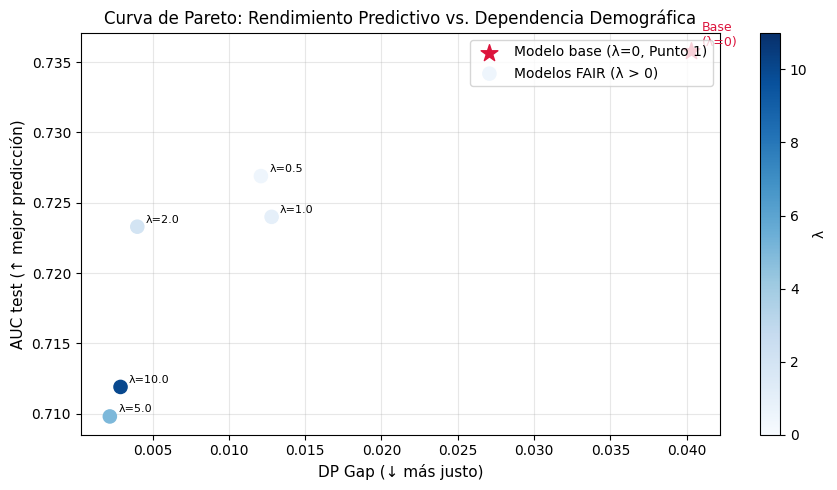

Gráfico de Pareto guardado en: outputs\pareto_fair_punto2.png


In [39]:
pareto_base = {"lambda": 0.0, "test_auc": auc_test, "dp_gap": dp_gap_base}

fig, ax = plt.subplots(figsize=(9, 5))

ax.scatter(
    pareto_base["dp_gap"], pareto_base["test_auc"],
    s=160, marker="*", color="crimson", zorder=5, label="Modelo base (λ=0, Punto 1)"
)
ax.annotate(
    "Base\n(λ=0)", (pareto_base["dp_gap"], pareto_base["test_auc"]),
    textcoords="offset points", xytext=(8, 4), fontsize=9, color="crimson",
)

sc = ax.scatter(
    fair_results_df["dp_gap"], fair_results_df["test_auc"],
    s=90, c=fair_results_df["lambda"], cmap="Blues",
    vmin=0, vmax=fair_results_df["lambda"].max() * 1.1,
    zorder=4, label="Modelos FAIR (λ > 0)",
)
plt.colorbar(sc, ax=ax, label="λ")

for _, row in fair_results_df.iterrows():
    ax.annotate(
        f"λ={row['lambda']}", (row["dp_gap"], row["test_auc"]),
        textcoords="offset points", xytext=(6, 3), fontsize=8,
    )

ax.set_xlabel("DP Gap (↓ más justo)", fontsize=11)
ax.set_ylabel("AUC test (↑ mejor predicción)", fontsize=11)
ax.set_title("Curva de Pareto: Rendimiento Predictivo vs. Dependencia Demográfica", fontsize=12)
ax.legend(loc="upper right")
ax.grid(alpha=0.3)
plt.tight_layout()

pareto_path = OUTPUT_DIR / "pareto_fair_punto2.png"
plt.savefig(pareto_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico de Pareto guardado en: {pareto_path}")

In [40]:
best_lam = fair_results_df.loc[fair_results_df["dp_gap"].idxmin(), "lambda"]
y_proba_best_fair = fair_probas[best_lam]
y_pred_best_fair = (y_proba_best_fair >= 0.5).astype(int)
y_pred_base = (y_test_proba >= 0.5).astype(int)

auc_best = roc_auc_score(y_test_np, y_proba_best_fair)
dp_best = compute_dp_gap(y_proba_best_fair, s_test.values)
bal_acc_base = balanced_accuracy_score(y_test_np, y_pred_base)
bal_acc_best = balanced_accuracy_score(y_test_np, y_pred_best_fair)

_, recall_base_c1, f1_base_c1, _ = precision_recall_fscore_support(
    y_test_np, y_pred_base, labels=[1], zero_division=0
)
_, recall_best_c1, f1_best_c1, _ = precision_recall_fscore_support(
    y_test_np, y_pred_best_fair, labels=[1], zero_division=0
)

comparison_df = pd.DataFrame([
    {
        "Modelo": "Base (λ=0, Punto 1)",
        "AUC test": round(auc_test, 4),
        "DP Gap": round(dp_gap_base, 4),
        "Balanced Acc.": round(bal_acc_base, 4),
        "Recall clase 1": round(recall_base_c1[0], 4),
        "F1 clase 1": round(f1_base_c1[0], 4),
        "λ": 0.0,
    },
    {
        "Modelo": f"Mejor FAIR (λ={best_lam})",
        "AUC test": round(auc_best, 4),
        "DP Gap": round(dp_best, 4),
        "Balanced Acc.": round(bal_acc_best, 4),
        "Recall clase 1": round(recall_best_c1[0], 4),
        "F1 clase 1": round(f1_best_c1[0], 4),
        "λ": best_lam,
    },
])

print("Tabla comparativa: Modelo Base vs. Mejor Modelo FAIR")
print(f"(Mejor FAIR = λ={best_lam}, DP gap mínimo en test)")
display(comparison_df)

auc_reduction = auc_test - auc_best
dp_improvement = dp_gap_base - dp_best
print(f"\nReducción de AUC:   {auc_reduction:+.4f}")
print(f"Mejora en DP Gap:   {dp_improvement:+.4f}  ({100 * dp_improvement / dp_gap_base:.1f}% de reducción)")

comparison_path = OUTPUT_DIR / "comparison_base_vs_fair_punto2.csv"
comparison_df.to_csv(comparison_path, index=False)
print(f"\nTabla guardada en: {comparison_path}")

Tabla comparativa: Modelo Base vs. Mejor Modelo FAIR
(Mejor FAIR = λ=5.0, DP gap mínimo en test)


,Modelo,AUC test,DP Gap,Balanced Acc.,Recall clase 1,F1 clase 1,λ
0,"Base (λ=0, Punto 1)",0.7358,0.0403,0.6724,0.6606,0.2514,0.0
1,Mejor FAIR (λ=5.0),0.7098,0.0022,0.6530,0.5797,0.2469,5.0



Reducción de AUC:   +0.0260
Mejora en DP Gap:   +0.0381  (94.5% de reducción)

Tabla guardada en: outputs\comparison_base_vs_fair_punto2.csv


### Penalización adicional: CKA (Centered Kernel Alignment)

El **Demographic Parity Gap** captura diferencias de media entre grupos, pero puede pasar por alto dependencias más sutiles entre $\hat{y}$ y $s$ (por ejemplo, si la distribución de predicciones está correlacionada con el género aunque sus medias sean iguales). Para complementarlo se añade **CKA lineal** como segunda penalización.

CKA mide la alineación entre dos conjuntos de representaciones mediante HSIC:

$$\text{CKA}(K, L) = \frac{\text{HSIC}(K, L)}{\sqrt{\text{HSIC}(K,K) \cdot \text{HSIC}(L,L)}}$$

Para vectores 1D con kernel lineal ($K = \hat{y}\hat{y}^\top$, $L = ss^\top$), desarrollando la traza con el centrador $H = I - \frac{1}{n}\mathbf{1}\mathbf{1}^\top$, se puede demostrar que:

$$\text{CKA}_\text{lineal}(\hat{y}, s) = \left(\frac{\tilde{\hat{y}} \cdot \tilde{s}}{\|\tilde{\hat{y}}\|\|\tilde{s}\|}\right)^2 = \text{corr}(\hat{y}, s)^2$$

Es decir, **CKA lineal es exactamente el cuadrado de la correlación de Pearson** entre las predicciones y el género. Esto lo hace interpretable y eficiente de calcular en cada batch de TensorFlow.

La función de coste combinada queda:

$$L_\text{DP+CKA}(\lambda) = \text{BCE}(y, \hat{y}) + \lambda \cdot \underbrace{|\mathbb{E}[\hat{y}|s{=}1] - \mathbb{E}[\hat{y}|s{=}0]|}_{\text{DP gap}} + \lambda \cdot \underbrace{\text{corr}(\hat{y}, s)^2}_{\text{CKA}}$$

donde se usa el mismo λ para ambos términos de justicia para mantener la comparación con el sweep anterior.

In [41]:
def compute_cka_np(y_proba, s_array):
    """CKA lineal = corr(ŷ, s)² sobre arrays numpy.

    Para kernel lineal con vectores 1D, CKA se reduce al cuadrado de la
    correlación de Pearson, lo que es eficiente de calcular y fácil de interpretar.
    """
    a = np.asarray(y_proba, dtype="float64")
    b = np.asarray(s_array, dtype="float64")
    a_c = a - a.mean()
    b_c = b - b.mean()
    num = float(np.dot(a_c, b_c)) ** 2
    denom = float(np.dot(a_c, a_c) * np.dot(b_c, b_c)) + 1e-8
    return num / denom


def make_combined_fair_loss(lambda_dp, lambda_cka):
    """BCE + λ₁·DP_gap + λ₂·CKA_lineal(ŷ, s).

    CKA lineal = corr(ŷ, s)² — penaliza la correlación global entre predicciones
    y género, capturando dependencias que el DP gap (solo diferencias de media)
    puede pasar por alto.

    Espera y_true con forma (batch, 2): columna 0 = TARGET, columna 1 = CODE_GENDER.
    Devuelve shape (batch,) para compatibilidad con sample_weight.
    """
    def combined_fair_bce(y_combined, y_pred):
        y_true = tf.cast(y_combined[:, 0:1], tf.float32)
        s = tf.cast(y_combined[:, 1:2], tf.float32)

        bce_per_sample = tf.keras.losses.binary_crossentropy(y_true, y_pred)

        y_flat = tf.squeeze(y_pred, axis=-1)
        s_flat = tf.squeeze(s, axis=-1)

        # DP gap: diferencia de medias entre grupos
        n0 = tf.reduce_sum(1.0 - s_flat) + 1e-8
        n1 = tf.reduce_sum(s_flat) + 1e-8
        mean_0 = tf.reduce_sum(y_flat * (1.0 - s_flat)) / n0
        mean_1 = tf.reduce_sum(y_flat * s_flat) / n1
        dp_gap_batch = tf.abs(mean_1 - mean_0)

        # CKA lineal: corr(ŷ, s)² — mide dependencia global en el batch
        y_c = y_flat - tf.reduce_mean(y_flat)
        s_c = s_flat - tf.reduce_mean(s_flat)
        cka = tf.square(tf.reduce_sum(y_c * s_c)) / (
            tf.reduce_sum(tf.square(y_c)) * tf.reduce_sum(tf.square(s_c)) + 1e-8
        )

        return bce_per_sample + lambda_dp * dp_gap_batch + lambda_cka * cka

    combined_fair_bce.__name__ = f"combined_dp{lambda_dp}_cka{lambda_cka}"
    return combined_fair_bce


cka_base = compute_cka_np(y_test_proba, s_test.values.astype("float64"))
print(f"CKA modelo base (Punto 1):  {cka_base:.6f}")
print(f"  corr(ŷ, s) de Pearson:   {np.sqrt(cka_base):.4f}  (raíz del CKA)")
print(f"DP gap modelo base:          {dp_gap_base:.4f}")

CKA modelo base (Punto 1):  0.012162
  corr(ŷ, s) de Pearson:   0.1103  (raíz del CKA)
DP gap modelo base:          0.0403


### Sweep 2: CKA lineal solo

`BCE + lambda * CKA_lineal(y, s)` con `lambda_dp = 0`.

CKA lineal = corr(y,s)^2 es estrictamente mas fuerte que el DP gap (DP gap = 0 si y solo si la media de y es igual en ambos grupos; CKA = 0 si y solo si la correlacion lineal completa es cero). No se combina con DP gap porque ambos penalizan la misma cantidad.

In [42]:
cka_results     = []
cka_probas_dict = {}

for lam in LAMBDA_VALUES:
    print(f"Entrenando CKA_lin solo lambda={lam} ...", end=" ", flush=True)

    model_cka = build_custom_debt_model(n_scaled_features=X_train_scaled_np.shape[1])
    model_cka.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=make_combined_fair_loss(lambda_dp=0.0, lambda_cka=lam),
        metrics=[],
    )
    model_cka.fit(
        x={"scaled_features": X_train_scaled_np, "financial_raw": X_train_financial_raw},
        y=y_train_combined,
        validation_data=(
            {"scaled_features": X_val_scaled_np, "financial_raw": X_val_financial_raw},
            y_val_combined,
        ),
        sample_weight=sample_weight_train,
        epochs=EPOCHS_FAIR,
        batch_size=BATCH_SIZE_FAIR,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss", mode="min",
                patience=5, restore_best_weights=True, verbose=0,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss", mode="min",
                factor=0.5, patience=3, min_lr=1e-5, verbose=0,
            ),
        ],
        verbose=0,
    )
    yp = model_cka.predict(
        {"scaled_features": X_test_scaled_np, "financial_raw": X_test_financial_raw},
        batch_size=1024, verbose=0,
    ).ravel()
    cka_probas_dict[lam] = yp
    s_np  = s_test.values.astype("float64")
    auc_c = roc_auc_score(y_test_np, yp)
    dp_c  = compute_dp_gap(yp, s_np)
    cka_c = compute_cka_np(yp, s_np)
    cka_results.append({
        "lambda": lam, "test_auc": round(auc_c, 4),
        "dp_gap": round(dp_c, 4), "cka_lin": round(cka_c, 6),
    })
    print(f"AUC={auc_c:.4f}  DP gap={dp_c:.4f}  CKA_lin={cka_c:.4f}")

cka_results_df = pd.DataFrame(cka_results)
cka_results_df.to_csv(OUTPUT_DIR / "sweep_cka_lin_only.csv", index=False)
print("\nResultados sweep CKA lineal solo:")
display(cka_results_df)

Entrenando CKA_lin solo lambda=0.5 ... AUC=0.7302  DP gap=0.0263  CKA_lin=0.0054
Entrenando CKA_lin solo lambda=1.0 ... AUC=0.7288  DP gap=0.0173  CKA_lin=0.0024
Entrenando CKA_lin solo lambda=2.0 ... AUC=0.7267  DP gap=0.0185  CKA_lin=0.0034
Entrenando CKA_lin solo lambda=5.0 ... AUC=0.7296  DP gap=0.0087  CKA_lin=0.0006
Entrenando CKA_lin solo lambda=10.0 ... AUC=0.7216  DP gap=0.0084  CKA_lin=0.0007

Resultados sweep CKA lineal solo:


,lambda,test_auc,dp_gap,cka_lin
0,0.5,0.7302,0.0263,0.005382
1,1.0,0.7288,0.0173,0.002433
2,2.0,0.7267,0.0185,0.003361
3,5.0,0.7296,0.0087,0.000645
4,10.0,0.7216,0.0084,0.000743


### Sweep 3: MI solo

`BCE + lambda * MI_suave(y, s)` con `lambda_dp = 0`.

MI es condicion mas fuerte que el DP gap: MI = 0 implica independencia estadistica completa entre y y s (no solo igualdad de medias). No se combina con DP gap porque MI lo subsume.

In [43]:
def mutual_information_soft(y_pred_flat, s_flat, n_bins=20):
    """MI(y,s) diferenciable via soft histogram. s binaria, y en [0,1]."""
    centers = tf.linspace(0.0, 1.0, n_bins)            # (K,)
    sigma = 1.0 / n_bins
    y_exp = tf.expand_dims(y_pred_flat, 1)             # (batch, 1)
    c_exp = tf.expand_dims(centers, 0)                 # (1, K)
    soft_w = tf.exp(-0.5 * tf.square((y_exp - c_exp) / sigma))
    soft_w = soft_w / (tf.reduce_sum(soft_w, axis=1, keepdims=True) + 1e-8)
    p_bin   = tf.reduce_mean(soft_w, axis=0) + 1e-8   # (K,)
    p_bin_s0 = tf.reduce_mean(soft_w * tf.expand_dims(1.0 - s_flat, 1), axis=0) + 1e-8
    p_bin_s1 = tf.reduce_mean(soft_w * tf.expand_dims(s_flat, 1),       axis=0) + 1e-8
    p_s0 = tf.reduce_mean(1.0 - s_flat) + 1e-8
    p_s1 = tf.reduce_mean(s_flat)        + 1e-8
    h_s  = -(p_s0 * tf.math.log(p_s0) + p_s1 * tf.math.log(p_s1))
    ps0g = p_bin_s0 / p_bin
    ps1g = p_bin_s1 / p_bin
    h_s_given_bin = -(ps0g * tf.math.log(ps0g + 1e-8) + ps1g * tf.math.log(ps1g + 1e-8))
    h_s_given_y   = tf.reduce_sum(p_bin * h_s_given_bin)
    return tf.maximum(h_s - h_s_given_y, 0.0)


def compute_mi_np(y_proba, s_array, n_bins=20):
    """Misma logica en numpy para evaluacion post-entrenamiento."""
    y = np.asarray(y_proba, dtype="float64")
    s = np.asarray(s_array, dtype="float64")
    centers = np.linspace(0, 1, n_bins)
    sigma   = 1.0 / n_bins
    diff = y[:, None] - centers[None, :]
    sw   = np.exp(-0.5 * (diff / sigma) ** 2)
    sw   = sw / (sw.sum(axis=1, keepdims=True) + 1e-8)
    p_bin  = sw.mean(axis=0) + 1e-8
    p_bs0  = (sw * (1 - s)[:, None]).mean(axis=0) + 1e-8
    p_bs1  = (sw * s[:, None]).mean(axis=0)        + 1e-8
    p_s0   = (1 - s).mean() + 1e-8
    p_s1   = s.mean()       + 1e-8
    h_s    = -(p_s0 * np.log(p_s0) + p_s1 * np.log(p_s1))
    ps0g   = p_bs0 / p_bin
    ps1g   = p_bs1 / p_bin
    h_cond = (p_bin * (-(ps0g * np.log(ps0g + 1e-8) + ps1g * np.log(ps1g + 1e-8)))).sum()
    return max(0.0, float(h_s - h_cond))


def make_mi_fair_loss(lambda_dp, lambda_mi, n_bins=20):
    """BCE + lambda_dp * DP_gap + lambda_mi * MI_suave(y, s)."""
    def mi_fair_bce(y_combined, y_pred):
        y_true = tf.cast(y_combined[:, 0:1], tf.float32)
        s      = tf.cast(y_combined[:, 1:2], tf.float32)
        bce_per_sample = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        y_flat = tf.squeeze(y_pred, axis=-1)
        s_flat = tf.squeeze(s,      axis=-1)
        n0 = tf.reduce_sum(1.0 - s_flat) + 1e-8
        n1 = tf.reduce_sum(s_flat)        + 1e-8
        dp_gap_batch = tf.abs(
            tf.reduce_sum(y_flat * s_flat)        / n1
          - tf.reduce_sum(y_flat * (1.0 - s_flat)) / n0
        )
        mi = mutual_information_soft(y_flat, s_flat, n_bins=n_bins)
        return bce_per_sample + lambda_dp * dp_gap_batch + lambda_mi * mi
    mi_fair_bce.__name__ = f"mi_fair_dp{lambda_dp}_mi{lambda_mi}"
    return mi_fair_bce


mi_base = compute_mi_np(y_test_proba, s_test.values.astype("float64"))
print(f"MI base (Punto 1): {mi_base:.6f} nats  (max teorico = H(s) = {-(0.33*np.log(0.33+1e-8)+0.67*np.log(0.67+1e-8)):.4f})")
print(f"CKA base:          {cka_base:.6f}")
print(f"DP gap base:       {dp_gap_base:.4f}")

MI base (Punto 1): 0.005668 nats  (max teorico = H(s) = 0.6342)
CKA base:          0.012162
DP gap base:       0.0403


In [44]:
mi_results     = []
mi_probas_dict = {}

for lam in LAMBDA_VALUES:
    print(f"Entrenando MI solo lambda={lam} ...", end=" ", flush=True)
    model_mi = build_custom_debt_model(n_scaled_features=X_train_scaled_np.shape[1])
    model_mi.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=make_mi_fair_loss(lambda_dp=0.0, lambda_mi=lam),
        metrics=[],
    )
    model_mi.fit(
        x={"scaled_features": X_train_scaled_np, "financial_raw": X_train_financial_raw},
        y=y_train_combined,
        validation_data=(
            {"scaled_features": X_val_scaled_np, "financial_raw": X_val_financial_raw},
            y_val_combined,
        ),
        sample_weight=sample_weight_train,
        epochs=EPOCHS_FAIR,
        batch_size=BATCH_SIZE_FAIR,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss", mode="min",
                patience=5, restore_best_weights=True, verbose=0,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss", mode="min",
                factor=0.5, patience=3, min_lr=1e-5, verbose=0,
            ),
        ],
        verbose=0,
    )
    yp = model_mi.predict(
        {"scaled_features": X_test_scaled_np, "financial_raw": X_test_financial_raw},
        batch_size=1024, verbose=0,
    ).ravel()
    mi_probas_dict[lam] = yp
    s_np  = s_test.values.astype("float64")
    auc_m = roc_auc_score(y_test_np, yp)
    dp_m  = compute_dp_gap(yp, s_np)
    mi_m  = compute_mi_np(yp, s_np)
    mi_results.append({
        "lambda": lam, "test_auc": round(auc_m, 4),
        "dp_gap": round(dp_m, 4), "mi": round(mi_m, 6),
    })
    print(f"AUC={auc_m:.4f}  DP gap={dp_m:.4f}  MI={mi_m:.4f}")

mi_results_df = pd.DataFrame(mi_results)
mi_results_df.to_csv(OUTPUT_DIR / "sweep_mi_only.csv", index=False)
print("\nResultados sweep MI solo:")
display(mi_results_df)

Entrenando MI solo lambda=0.5 ... AUC=0.7295  DP gap=0.0285  MI=0.0032
Entrenando MI solo lambda=1.0 ... AUC=0.7289  DP gap=0.0251  MI=0.0025
Entrenando MI solo lambda=2.0 ... AUC=0.7313  DP gap=0.0194  MI=0.0014
Entrenando MI solo lambda=5.0 ... AUC=0.7284  DP gap=0.0120  MI=0.0006
Entrenando MI solo lambda=10.0 ... AUC=0.7219  DP gap=0.0097  MI=0.0005

Resultados sweep MI solo:


,lambda,test_auc,dp_gap,mi
0,0.5,0.7295,0.0285,0.003159
1,1.0,0.7289,0.0251,0.002458
2,2.0,0.7313,0.0194,0.001367
3,5.0,0.7284,0.0120,0.000578
4,10.0,0.7219,0.0097,0.000507


### Sweep 4: DP gap + CKA RBF

`BCE + lambda * DP_gap + lambda * CKA_RBF(y, s)` — la combinacion mas justificada: DP gap controla las diferencias de media con gradiente limpio O(n), y CKA RBF anade informacion sobre la forma completa de la distribucion condicional (varianza, asimetria, colas).

Gamma = 0.5 fijo durante entrenamiento (heuristica de la mediana en evaluacion).

In [ ]:
def cka_rbf_tf(y_pred_flat, s_flat, gamma=0.5):
    """CKA con kernel RBF entre predicciones y variable sensible (TF).

    Computa matrices de kernel (n,n) — O(n^2). Con batch_size=1024 son ~1M
    entradas, manejable en GPU/CPU.
    """
    y = tf.expand_dims(y_pred_flat, 1)          # (n, 1)
    s = tf.expand_dims(s_flat, 1)               # (n, 1)

    K = tf.exp(-tf.square(y - tf.transpose(y)) / (2.0 * gamma ** 2))
    L = tf.exp(-tf.square(s - tf.transpose(s)) / (2.0 * gamma ** 2))

    def center(M):
        row_m   = tf.reduce_mean(M, axis=1, keepdims=True)
        col_m   = tf.reduce_mean(M, axis=0, keepdims=True)
        grand_m = tf.reduce_mean(M)
        return M - row_m - col_m + grand_m

    K_c = center(K)
    L_c = center(L)

    n = tf.cast(tf.shape(y_pred_flat)[0], tf.float32)
    denom_sq = tf.square(n - 1.0)

    hsic_kl = tf.reduce_sum(K_c * L_c) / denom_sq
    hsic_kk = tf.reduce_sum(K_c * K_c) / denom_sq
    hsic_ll = tf.reduce_sum(L_c * L_c) / denom_sq

    return tf.maximum(hsic_kl / (tf.sqrt(hsic_kk * hsic_ll) + 1e-8), 0.0)


def compute_cka_rbf_np(y_proba, s_array, gamma=None):
    """CKA RBF en numpy. Si gamma=None usa la heuristica de la mediana."""
    y = np.asarray(y_proba, dtype="float64")
    s = np.asarray(s_array, dtype="float64")

    if gamma is None:
        # Mediana de distancias entre predicciones como estimacion de gamma
        diffs = np.abs(y[:, None] - y[None, :])
        gamma = float(np.median(diffs[diffs > 0])) + 1e-8

    K = np.exp(-np.square(y[:, None] - y[None, :]) / (2.0 * gamma ** 2))
    L = np.exp(-np.square(s[:, None] - s[None, :]) / (2.0 * gamma ** 2))

    def center(M):
        return M - M.mean(axis=1, keepdims=True) - M.mean(axis=0, keepdims=True) + M.mean()

    K_c = center(K)
    L_c = center(L)
    n = len(y)
    d2 = (n - 1) ** 2

    hsic_kl = (K_c * L_c).sum() / d2
    hsic_kk = (K_c * K_c).sum() / d2
    hsic_ll = (L_c * L_c).sum() / d2

    return float(max(hsic_kl / (np.sqrt(hsic_kk * hsic_ll) + 1e-8), 0.0))


def make_rbf_fair_loss(lambda_dp, lambda_rbf, gamma=0.5):
    """BCE + lambda_dp * DP_gap + lambda_rbf * CKA_RBF(y, s)."""
    def rbf_fair_bce(y_combined, y_pred):
        y_true = tf.cast(y_combined[:, 0:1], tf.float32)
        s      = tf.cast(y_combined[:, 1:2], tf.float32)
        bce_per_sample = tf.keras.losses.binary_crossentropy(y_true, y_pred)
        y_flat = tf.squeeze(y_pred, axis=-1)
        s_flat = tf.squeeze(s, axis=-1)
        n0 = tf.reduce_sum(1.0 - s_flat) + 1e-8
        n1 = tf.reduce_sum(s_flat)        + 1e-8
        dp_gap_batch = tf.abs(
            tf.reduce_sum(y_flat * s_flat)         / n1
          - tf.reduce_sum(y_flat * (1.0 - s_flat)) / n0
        )
        rbf_cka = cka_rbf_tf(y_flat, s_flat, gamma=gamma)
        return bce_per_sample + lambda_dp * dp_gap_batch + lambda_rbf * rbf_cka
    rbf_fair_bce.__name__ = f"rbf_fair_dp{lambda_dp}_rbf{lambda_rbf}"
    return rbf_fair_bce


# Medida de CKA RBF en el modelo base
cka_rbf_base = compute_cka_rbf_np(y_test_proba, s_test.values.astype("float64"))
print(f"CKA RBF base (mediana gamma): {cka_rbf_base:.6f}")
print(f"CKA lin base (= corr^2):      {cka_base:.6f}")
print(f"  -> CKA RBF > CKA lin indica dependencias no lineales adicionales")

In [ ]:
rbf_results     = []
rbf_probas_dict = {}

for lam in LAMBDA_VALUES:
    print(f"Entrenando DP+CKA_RBF lambda={lam} ...", end=" ", flush=True)
    model_rbf = build_custom_debt_model(n_scaled_features=X_train_scaled_np.shape[1])
    model_rbf.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=make_rbf_fair_loss(lambda_dp=lam, lambda_rbf=lam, gamma=0.5),
        metrics=[],
    )
    model_rbf.fit(
        x={"scaled_features": X_train_scaled_np, "financial_raw": X_train_financial_raw},
        y=y_train_combined,
        validation_data=(
            {"scaled_features": X_val_scaled_np, "financial_raw": X_val_financial_raw},
            y_val_combined,
        ),
        sample_weight=sample_weight_train,
        epochs=EPOCHS_FAIR,
        batch_size=BATCH_SIZE_FAIR,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss", mode="min",
                patience=5, restore_best_weights=True, verbose=0,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss", mode="min",
                factor=0.5, patience=3, min_lr=1e-5, verbose=0,
            ),
        ],
        verbose=0,
    )
    yp = model_rbf.predict(
        {"scaled_features": X_test_scaled_np, "financial_raw": X_test_financial_raw},
        batch_size=1024, verbose=0,
    ).ravel()
    rbf_probas_dict[lam] = yp
    s_np     = s_test.values.astype("float64")
    auc_r    = roc_auc_score(y_test_np, yp)
    dp_r     = compute_dp_gap(yp, s_np)
    cka_l_r  = compute_cka_np(yp, s_np)
    cka_rbf_r= compute_cka_rbf_np(yp, s_np)
    mi_r     = compute_mi_np(yp, s_np)
    rbf_results.append({
        "lambda":   lam,
        "test_auc": round(auc_r,     4),
        "dp_gap":   round(dp_r,      4),
        "cka_lin":  round(cka_l_r,   6),
        "cka_rbf":  round(cka_rbf_r, 6),
        "mi":       round(mi_r,      6),
    })
    print(f"AUC={auc_r:.4f}  DP gap={dp_r:.4f}  CKA_lin={cka_l_r:.4f}  CKA_rbf={cka_rbf_r:.4f}")

rbf_results_df = pd.DataFrame(rbf_results)
rbf_results_df.to_csv(OUTPUT_DIR / "fair_rbf_sweep_results.csv", index=False)
print("\nResultados sweep DP + CKA RBF:")
display(rbf_results_df)

### Sweep 5: CKA RBF solo

`BCE + lambda * CKA_RBF(y, s)` con `lambda_dp = 0`.

Penaliza directamente la dependencia no lineal completa entre predicciones y genero sin el termino auxiliar de DP gap. Al ser mas general que CKA lineal y que el DP gap, es la penalizacion de justicia mas fuerte de las cinco.

In [ ]:
rbf_only_results     = []
rbf_only_probas_dict = {}

for lam in LAMBDA_VALUES:
    print(f"Entrenando CKA_RBF solo lambda={lam} ...", end=" ", flush=True)
    model_rbf_only = build_custom_debt_model(n_scaled_features=X_train_scaled_np.shape[1])
    model_rbf_only.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=make_rbf_fair_loss(lambda_dp=0.0, lambda_rbf=lam, gamma=0.5),
        metrics=[],
    )
    model_rbf_only.fit(
        x={"scaled_features": X_train_scaled_np, "financial_raw": X_train_financial_raw},
        y=y_train_combined,
        validation_data=(
            {"scaled_features": X_val_scaled_np, "financial_raw": X_val_financial_raw},
            y_val_combined,
        ),
        sample_weight=sample_weight_train,
        epochs=EPOCHS_FAIR,
        batch_size=BATCH_SIZE_FAIR,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss", mode="min",
                patience=5, restore_best_weights=True, verbose=0,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss", mode="min",
                factor=0.5, patience=3, min_lr=1e-5, verbose=0,
            ),
        ],
        verbose=0,
    )
    yp = model_rbf_only.predict(
        {"scaled_features": X_test_scaled_np, "financial_raw": X_test_financial_raw},
        batch_size=1024, verbose=0,
    ).ravel()
    rbf_only_probas_dict[lam] = yp
    s_np      = s_test.values.astype("float64")
    auc_r     = roc_auc_score(y_test_np, yp)
    dp_r      = compute_dp_gap(yp, s_np)
    cka_rbf_r = compute_cka_rbf_np(yp, s_np)
    rbf_only_results.append({
        "lambda":   lam,
        "test_auc": round(auc_r,     4),
        "dp_gap":   round(dp_r,      4),
        "cka_rbf":  round(cka_rbf_r, 6),
    })
    print(f"AUC={auc_r:.4f}  DP gap={dp_r:.4f}  CKA_RBF={cka_rbf_r:.4f}")

rbf_only_results_df = pd.DataFrame(rbf_only_results)
rbf_only_results_df.to_csv(OUTPUT_DIR / "sweep_cka_rbf_only.csv", index=False)
print("\nResultados sweep CKA RBF solo:")
display(rbf_only_results_df)

In [ ]:
# Completar metricas faltantes en cada dataframe
s_np = s_test.values.astype("float64")

def ensure_metrics(df, probas):
    for metric, fn in [
        ("cka_lin", lambda p: compute_cka_np(p, s_np)),
        ("cka_rbf", lambda p: compute_cka_rbf_np(p, s_np)),
        ("mi",      lambda p: compute_mi_np(p, s_np)),
    ]:
        if metric not in df.columns:
            df[metric] = [round(fn(probas[r["lambda"]]), 6)
                          for _, r in df.iterrows()]

# Renombrar columna "cka" legacy si existe
for df in [cka_results_df, mi_results_df, rbf_results_df]:
    if "cka" in df.columns and "cka_lin" not in df.columns:
        df.rename(columns={"cka": "cka_lin"}, inplace=True)

ensure_metrics(fair_results_df,     fair_probas)
ensure_metrics(cka_results_df,      cka_probas_dict)
ensure_metrics(mi_results_df,       mi_probas_dict)
ensure_metrics(rbf_results_df,      rbf_probas_dict)
ensure_metrics(rbf_only_results_df, rbf_only_probas_dict)

# Tabla comparativa: mejor modelo de cada sweep
sweeps_all = [
    (fair_results_df,     fair_probas,          "dp_gap",  "DP only",      "BCE + DP gap"),
    (cka_results_df,      cka_probas_dict,      "cka_lin", "CKA lin solo", "BCE + CKA_lin"),
    (mi_results_df,       mi_probas_dict,       "mi",      "MI solo",      "BCE + MI"),
    (rbf_results_df,      rbf_probas_dict,      "cka_rbf", "DP+CKA RBF",  "BCE + DP gap + CKA_RBF"),
    (rbf_only_results_df, rbf_only_probas_dict, "cka_rbf", "CKA RBF solo","BCE + CKA_RBF"),
]

def _row(label, proba, loss_str):
    p = np.asarray(proba)
    return {
        "Modelo":      label,
        "Loss":        loss_str,
        "AUC":         round(roc_auc_score(y_test_np, p), 4),
        "DP Gap":      round(compute_dp_gap(p, s_np),     4),
        "CKA lineal":  round(compute_cka_np(p, s_np),     6),
        "CKA RBF":     round(compute_cka_rbf_np(p, s_np), 6),
        "MI [nats]":   round(compute_mi_np(p, s_np),      6),
    }

rows = [_row("Base (Punto 1)", y_test_proba, "BCE")]
for df, probas, opt_col, label, loss_str in sweeps_all:
    best_lam = df.loc[df[opt_col].idxmin(), "lambda"]
    rows.append(_row(f"{label} (lam={best_lam})", probas[best_lam], loss_str))

final_df = pd.DataFrame(rows)
print("Tabla comparativa final — cinco penalizaciones de justicia")
display(final_df)
final_df.to_csv(OUTPUT_DIR / "summary_all_fair_approaches.csv", index=False)
print(f"Guardada en: {OUTPUT_DIR / 'summary_all_fair_approaches.csv'}")

### Curva de Pareto: AUC vs DP Gap — todos los enfoques

Cada punto representa un modelo entrenado con un valor de lambda. La **curva de Pareto** muestra el frente optimo AUC-justicia: puntos en la esquina superior-izquierda son mejores (mayor AUC, menor DP gap).

Se incluye tambien AUC vs CKA RBF para comparar que metrica de dependencia cada penalizacion reduce mas eficientemente.

In [ ]:
sweeps_pareto = [
    (fair_results_df,     fair_probas,          "dp_gap",  "DP only",       "o",  "steelblue"),
    (cka_results_df,      cka_probas_dict,      "cka_lin", "CKA lin solo",  "s",  "darkorange"),
    (mi_results_df,       mi_probas_dict,       "mi",      "MI solo",       "^",  "seagreen"),
    (rbf_results_df,      rbf_probas_dict,      "cka_rbf", "DP + CKA RBF", "D",  "purple"),
    (rbf_only_results_df, rbf_only_probas_dict, "cka_rbf", "CKA RBF solo", "P",  "brown"),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (x_col, x_label, base_x) in zip(axes, [
    ("dp_gap",  "DP Gap",    dp_gap_base),
    ("cka_rbf", "CKA RBF",  cka_rbf_base),
]):
    ax.scatter([base_x], [auc_test], marker="*", s=300,
               color="crimson", zorder=6, label="Base (Punto 1)")

    for df, _, _, label, marker, color in sweeps_pareto:
        if x_col not in df.columns:
            continue
        xs   = df[x_col].values
        ys   = df["test_auc"].values
        lams = df["lambda"].values
        ax.scatter(xs, ys, marker=marker, color=color, s=80, label=label, zorder=5)
        order = xs.argsort()
        ax.plot(xs[order], ys[order], "--", color=color, alpha=0.4, linewidth=1)
        for idx in [0, -1]:
            ax.annotate(f"lam={lams[idx]}", (xs[idx], ys[idx]),
                        textcoords="offset points", xytext=(4, 3),
                        fontsize=6, color=color, alpha=0.8)

    ax.set_xlabel(x_label + " (menor = mas justo)")
    ax.set_ylabel("AUC en test (mayor = mejor)")
    ax.set_title(f"Pareto: AUC vs {x_label}")
    ax.legend(fontsize=8, loc="lower left")
    ax.grid(alpha=0.3)

plt.suptitle("Frente de Pareto — cinco penalizaciones de justicia\n"
             "esquina superior-izquierda = mejor compromiso rendimiento-equidad",
             fontsize=11)
plt.tight_layout()
pareto_path = OUTPUT_DIR / "pareto_all_approaches.png"
plt.savefig(pareto_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado en: {pareto_path}")

# Frente de Pareto no dominado (AUC vs DP gap)
all_pts = []
for df, _, _, label, _, _ in sweeps_pareto:
    for _, r in df.iterrows():
        all_pts.append({"Enfoque": label, "lambda": r["lambda"],
                        "AUC": r["test_auc"], "DP Gap": r["dp_gap"]})
all_pts.append({"Enfoque": "Base", "lambda": 0.0,
                "AUC": auc_test, "DP Gap": dp_gap_base})

all_pts_df = pd.DataFrame(all_pts).sort_values("DP Gap").reset_index(drop=True)
front, best_auc = [], -1
for _, row in all_pts_df.iterrows():
    if row["AUC"] >= best_auc:
        front.append(row)
        best_auc = row["AUC"]
front_df = pd.DataFrame(front).reset_index(drop=True)
print("\nFrente de Pareto no dominado:")
display(front_df)
front_df.to_csv(OUTPUT_DIR / "pareto_front_all.csv", index=False)

### Interpretación del trade-off justicia–rendimiento

La curva de Pareto muestra la frontera entre rendimiento predictivo (AUC) y equidad (DP gap). Un modelo perfectamente justo tendría DP gap = 0, pero esto implica ignorar toda señal que difiera entre géneros, incluyendo señales legítimas de riesgo.

**Qué mide el DP gap:** La diferencia absoluta en probabilidad media de impago asignada a hombres y mujeres. Un valor de cero significa que el modelo asigna idéntico riesgo medio a ambos grupos sin importar el género.

**Limitación de la paridad demográfica:** La paridad demográfica no implica igualdad de resultados individuales. Si los dos grupos tienen distribuciones de riesgo distintas por razones ajenas al género, forzar paridad puede penalizar a clientes con bajo riesgo real. La elección de la métrica de justicia debe responder al contexto regulatorio y ético del problema.

**Coste del ajuste:** La tabla de comparación cuantifica cuánto AUC se sacrifica al reducir el DP gap. Esta información es el insumo clave para decidir el valor de λ en producción, ponderando el rendimiento del sistema de scoring frente a las obligaciones de no discriminación.